# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

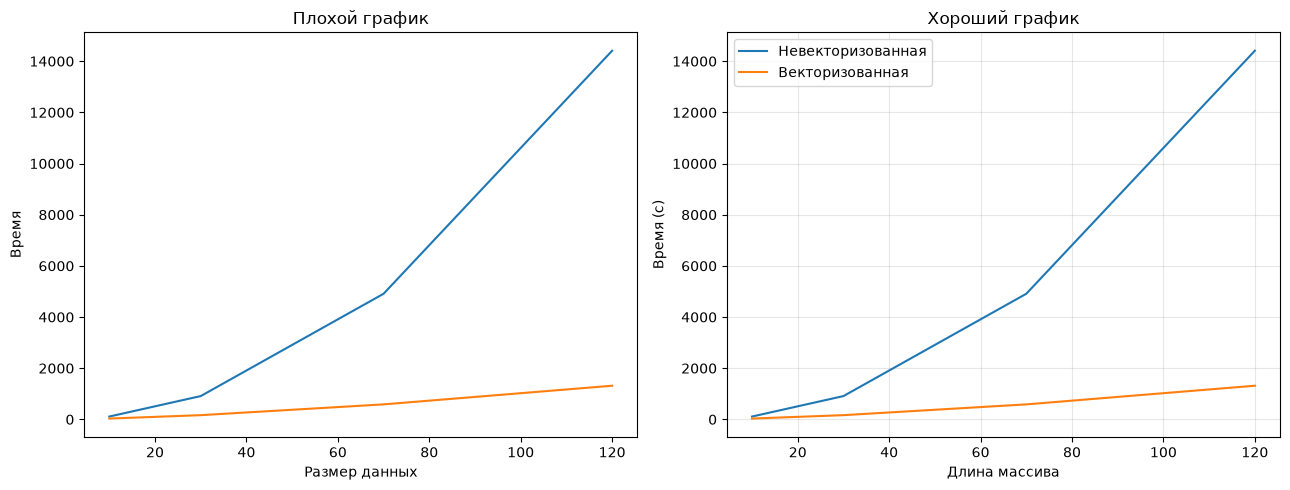

In [1]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


In [2]:
import time


def measure(func, args, repeats=10, warmup=1):
    """Минимальное время работы func(*args) среди repeats прогонов.

    min устойчивее среднего для микробенчмарков: он отбрасывает редкие
    всплески от GC, планировщика ОС, turbo-boost и прочего.
    """
    for _ in range(warmup):
        func(*args)
    best = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        func(*args)
        elapsed = time.perf_counter() - start
        if elapsed < best:
            best = elapsed
    return best


def fmt_size(n):
    if n >= 1_000_000:
        return f"{n / 1_000_000:g} млн"
    if n >= 1_000:
        return f"{n / 1_000:g} тыс."
    return str(n)


def plot_timing(title, sizes, t_nonvec, t_vec, xlabel, size_labels=None):
    if size_labels is None:
        size_labels = [fmt_size(s) for s in sizes]

    _, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(sizes, t_nonvec, "o-", label="Невекторизованная",
            linewidth=1.8, markersize=7, color="#d62728")
    ax.plot(sizes, t_vec, "s-", label="Векторизованная",
            linewidth=1.8, markersize=7, color="#1f77b4")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Время (с)", fontsize=11)
    ax.set_xticks(sizes)
    ax.set_xticklabels(size_labels, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.show()

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

In [3]:
reload_solution_modules()

print(functions.prod_non_zero_diag([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]))


3


In [4]:
reload_solution_modules()

print(functions_vectorized.prod_non_zero_diag(np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])))


3


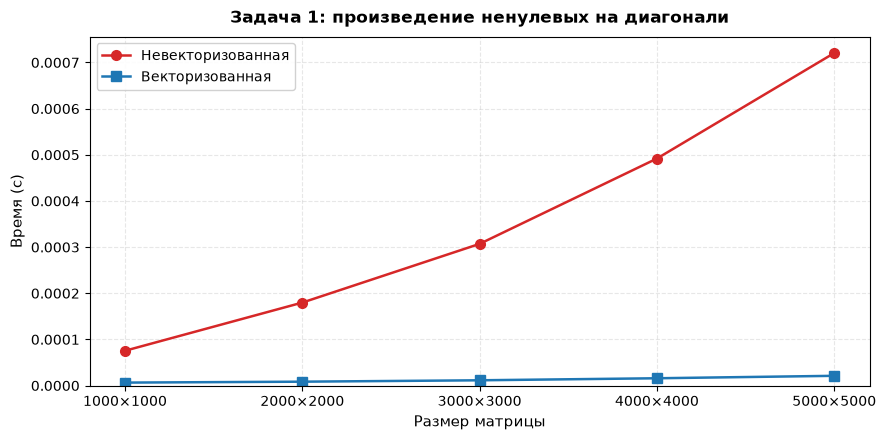

In [5]:
reload_solution_modules()

sizes = [1000, 2000, 3000, 4000, 5000]
t_nonvec, t_vec = [], []

for n in sizes:
    arr = np.random.randint(1, 5, size=(n, n), dtype=np.int8)
    arr_list = arr.tolist()
    t_nonvec.append(measure(functions.prod_non_zero_diag, (arr_list,),
                            repeats=50))
    t_vec.append(measure(functions_vectorized.prod_non_zero_diag, (arr,),
                         repeats=50))

plot_timing(
    "Задача 1: произведение ненулевых на диагонали",
    sizes, t_nonvec, t_vec,
    xlabel="Размер матрицы",
    size_labels=[f"{n}×{n}" for n in sizes],
)

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


In [6]:
reload_solution_modules()

print(functions.are_multisets_equal([1, 2, 2, 4], [4, 2, 1, 2]))


True


In [7]:
reload_solution_modules()

print(functions_vectorized.are_multisets_equal(np.array([1, 2, 2, 4]), np.array([4, 2, 1, 2])))


True


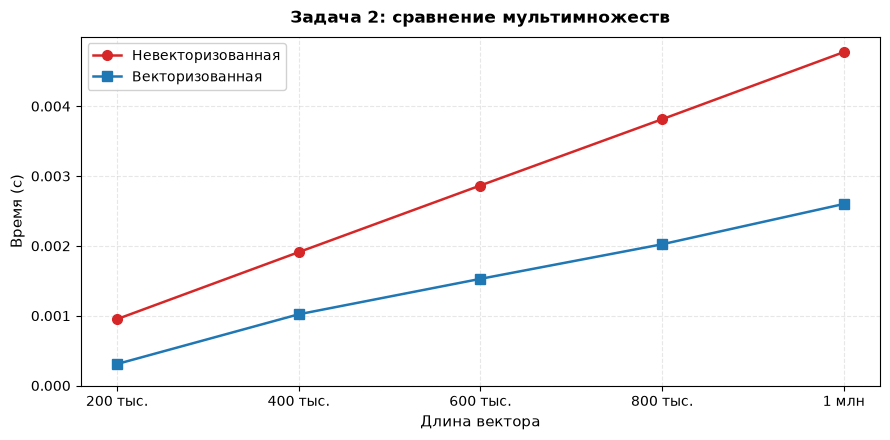

In [8]:
reload_solution_modules()

sizes = [200_000, 400_000, 600_000, 800_000, 1_000_000]
t_nonvec, t_vec = [], []

for n in sizes:
    base = np.random.randint(0, 20, size=n)
    a = np.random.permutation(base)
    b = np.random.permutation(base)
    t_nonvec.append(measure(functions.are_multisets_equal,
                            (a.tolist(), b.tolist())))
    t_vec.append(measure(functions_vectorized.are_multisets_equal, (a, b)))

plot_timing(
    "Задача 2: сравнение мультимножеств",
    sizes, t_nonvec, t_vec,
    xlabel="Длина вектора",
)

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

In [9]:
reload_solution_modules()

print(functions.max_after_zero([6, 2, 0, 3, 0, 0, 5, 7, 0]))
    

5


In [10]:
reload_solution_modules()

print(functions_vectorized.max_after_zero(np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])))
    

5


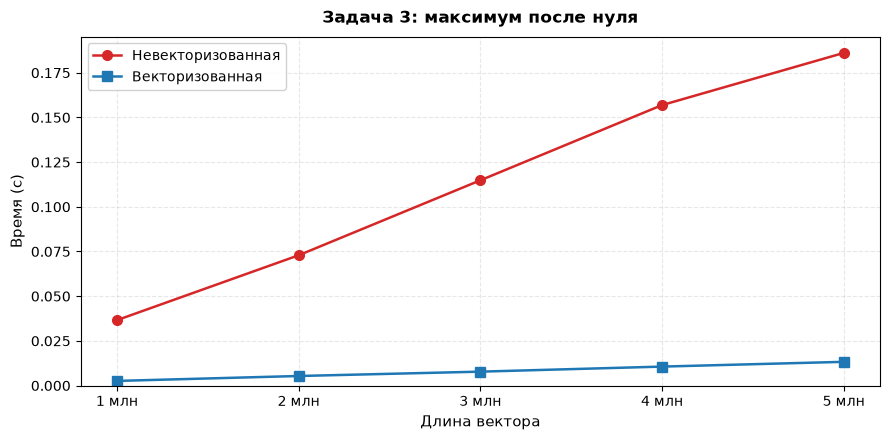

In [11]:
reload_solution_modules()

sizes = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]
t_nonvec, t_vec = [], []

for n in sizes:
    arr = np.random.randint(0, 4, size=n, dtype=np.int8)
    t_nonvec.append(measure(functions.max_after_zero, (arr.tolist(),)))
    t_vec.append(measure(functions_vectorized.max_after_zero, (arr,)))

plot_timing(
    "Задача 3: максимум после нуля",
    sizes, t_nonvec, t_vec,
    xlabel="Длина вектора",
)

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


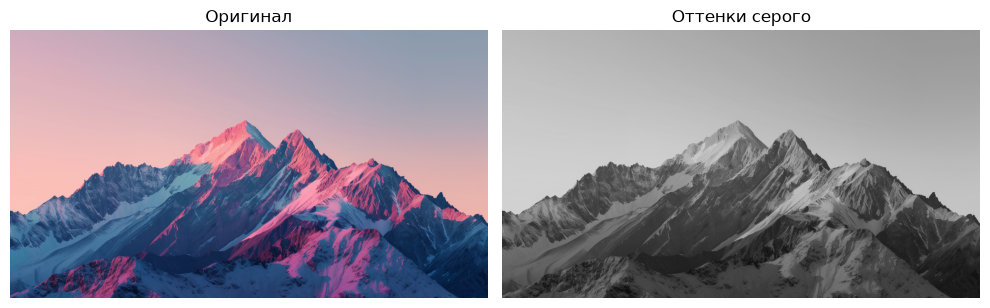

In [12]:
reload_solution_modules()

from PIL import Image

img = np.asarray(Image.open("f92a74e95baecce3f1b67d5c976547ce.png").convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])

gray = functions.convert_image(img, coefs)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Оригинал")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Оттенки серого")
plt.axis("off")

plt.tight_layout()
plt.show()

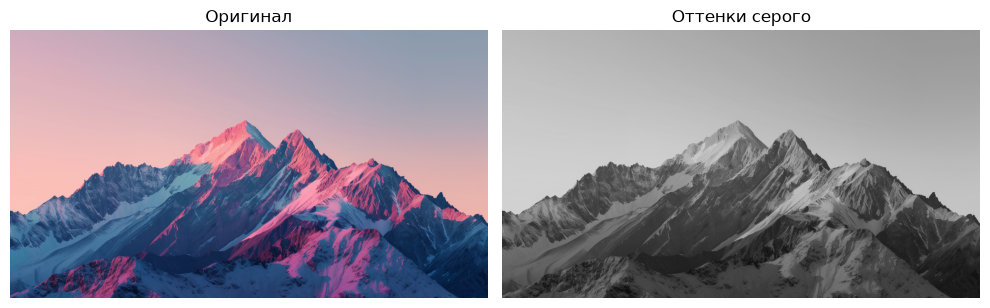

In [13]:
reload_solution_modules()

from PIL import Image

img = np.asarray(Image.open("f92a74e95baecce3f1b67d5c976547ce.png").convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])

gray = functions_vectorized.convert_image(img, coefs)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Оригинал")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Оттенки серого")
plt.axis("off")

plt.tight_layout()
plt.show()

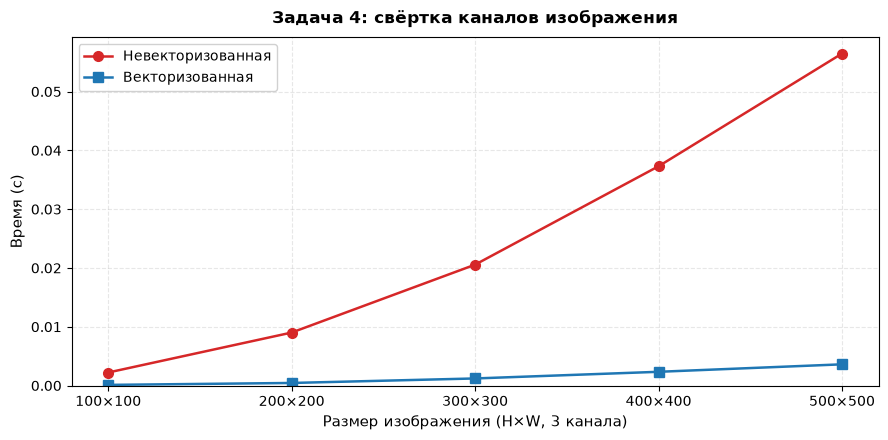

In [14]:
reload_solution_modules()

side_sizes = [100, 200, 300, 400, 500]
coefs = np.array([0.299, 0.587, 0.114])
t_nonvec, t_vec = [], []

for h in side_sizes:
    img = np.random.randint(0, 256, size=(h, h, 3), dtype=np.uint8)
    t_nonvec.append(measure(functions.convert_image,
                            (img.tolist(), coefs.tolist())))
    t_vec.append(measure(functions_vectorized.convert_image, (img, coefs)))

plot_timing(
    "Задача 4: свёртка каналов изображения",
    side_sizes, t_nonvec, t_vec,
    xlabel="Размер изображения (H×W, 3 канала)",
    size_labels=[f"{h}×{h}" for h in side_sizes],
)

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

In [15]:
reload_solution_modules()

print(functions.run_length_encoding([2, 2, 2, 3, 3, 3, 5]))


([2, 3, 5], [3, 3, 1])


In [16]:
reload_solution_modules()

print(functions_vectorized.run_length_encoding(np.array([2, 2, 2, 3, 3, 3, 5])))


(array([2, 3, 5]), array([3, 3, 1]))


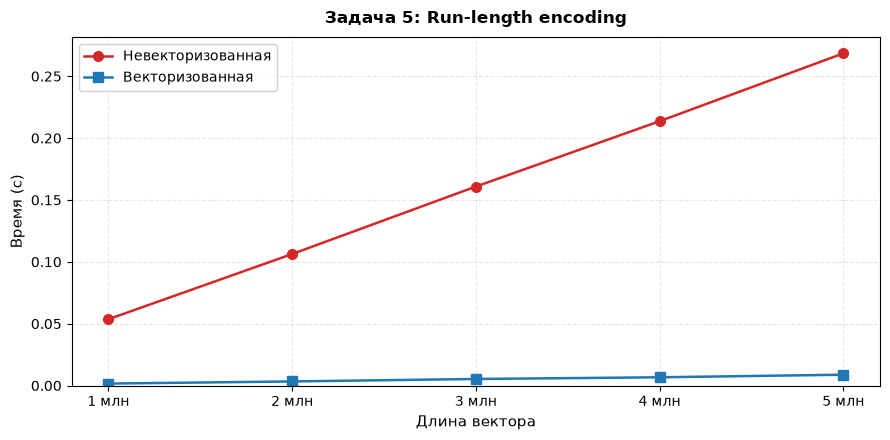

In [17]:
reload_solution_modules()

sizes = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]
t_nonvec, t_vec = [], []

for n in sizes:
    arr = np.repeat(np.random.randint(0, 10, size=n // 4), 4).astype(np.int8)
    t_nonvec.append(measure(functions.run_length_encoding, (arr.tolist(),)))
    t_vec.append(measure(functions_vectorized.run_length_encoding, (arr,)))

plot_timing(
    "Задача 5: Run-length encoding",
    sizes, t_nonvec, t_vec,
    xlabel="Длина вектора",
)

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

Все три реализации дают одинаковый результат.


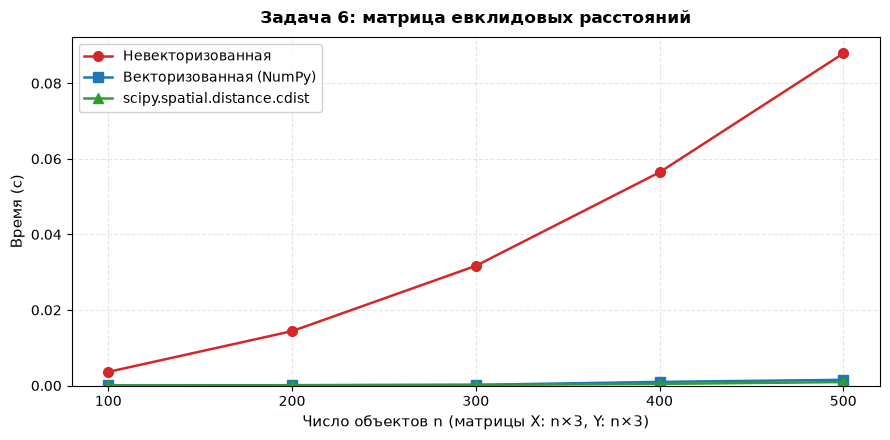

In [19]:
reload_solution_modules()

from scipy.spatial.distance import cdist

sizes = [100, 200, 300, 400, 500]
d = 3
t_nonvec, t_vec, t_scipy = [], [], []

for n in sizes:
    X = np.random.randn(n, d)
    Y = np.random.randn(n, d)
    t_nonvec.append(measure(functions.pairwise_distance,
                            (X.tolist(), Y.tolist())))
    t_vec.append(measure(functions_vectorized.pairwise_distance, (X, Y)))
    t_scipy.append(measure(cdist, (X, Y)))

X_chk = np.random.randn(50, d)
Y_chk = np.random.randn(50, d)
ref = cdist(X_chk, Y_chk)
assert np.allclose(functions_vectorized.pairwise_distance(X_chk, Y_chk), ref)
assert np.allclose(functions.pairwise_distance(X_chk.tolist(),
                                               Y_chk.tolist()), ref)
print("Все три реализации дают одинаковый результат.")

_, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sizes, t_nonvec, "o-", label="Невекторизованная",
        linewidth=1.8, markersize=7, color="#d62728")
ax.plot(sizes, t_vec, "s-", label="Векторизованная (NumPy)",
        linewidth=1.8, markersize=7, color="#1f77b4")
ax.plot(sizes, t_scipy, "^-", label="scipy.spatial.distance.cdist",
        linewidth=1.8, markersize=7, color="#2ca02c")

ax.set_title("Задача 6: матрица евклидовых расстояний",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Число объектов n (матрицы X: n×3, Y: n×3)", fontsize=11)
ax.set_ylabel("Время (с)", fontsize=11)
ax.set_xticks(sizes)
ax.set_xticklabels([str(n) for n in sizes], fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# Отчёт по ДЗ №1

## Что сделано

Реализованы **две версии** каждой задачи: *невекторизованная* на
питоновских циклах и ***векторизованная*** на NumPy.

## Методика

Функция `measure` берёт минимум по нескольким прогонам.

## Результаты

> Векторизованные версии быстрее, причём разрыв растёт с размером данных.
> На малых размерах разница почти незаметна из-за накладных расходов NumPy.

- В **задаче 1** обе версии обходят только диагональ, поэтому разрыв мал.
- В **задаче 6** `scipy.spatial.distance.cdist` быстрее NumPy-версии:
  написан на C.

## Туториал по Markdown

**Жирный**, *курсив*, `моноширинный код`, [ссылка на NumPy](https://numpy.org/).

> Цитата — как этот блок.
